In [17]:
import sys 
sys.path.append('../src')

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUDA_VISIBLE_DEVICES"] = "7"

from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
import torch, numpy as np
import matplotlib.pyplot as plt


In [7]:
from PIL import Image
import requests
from io import BytesIO

In [6]:
processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined")
model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined").cuda()
model.eval();

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Image size: 1920×1080


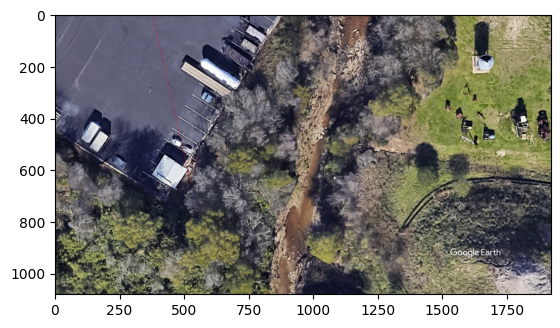

In [21]:
image = Image.open("../generated/sampled_disaster_city/frame_0016.jpg")
W, H  = image.size
print(f"Image size: {W}×{H}")

plt.imshow(image)

In [23]:
queries = ["parking lot", "river", "tree", "grass", "car", "building"]

In [24]:
inputs = processor(
    text    = queries,
    images  = [image] * len(queries),
    return_tensors = "pt",
    padding = True,
)
inputs = {k: v.to('cuda') for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)


In [25]:
logits = outputs.logits  # shape (4, 352, 352)

logits.shape

torch.Size([6, 352, 352])

In [26]:
relevancy = torch.sigmoid(logits).cpu().numpy()

relevancy.shape

(6, 352, 352)

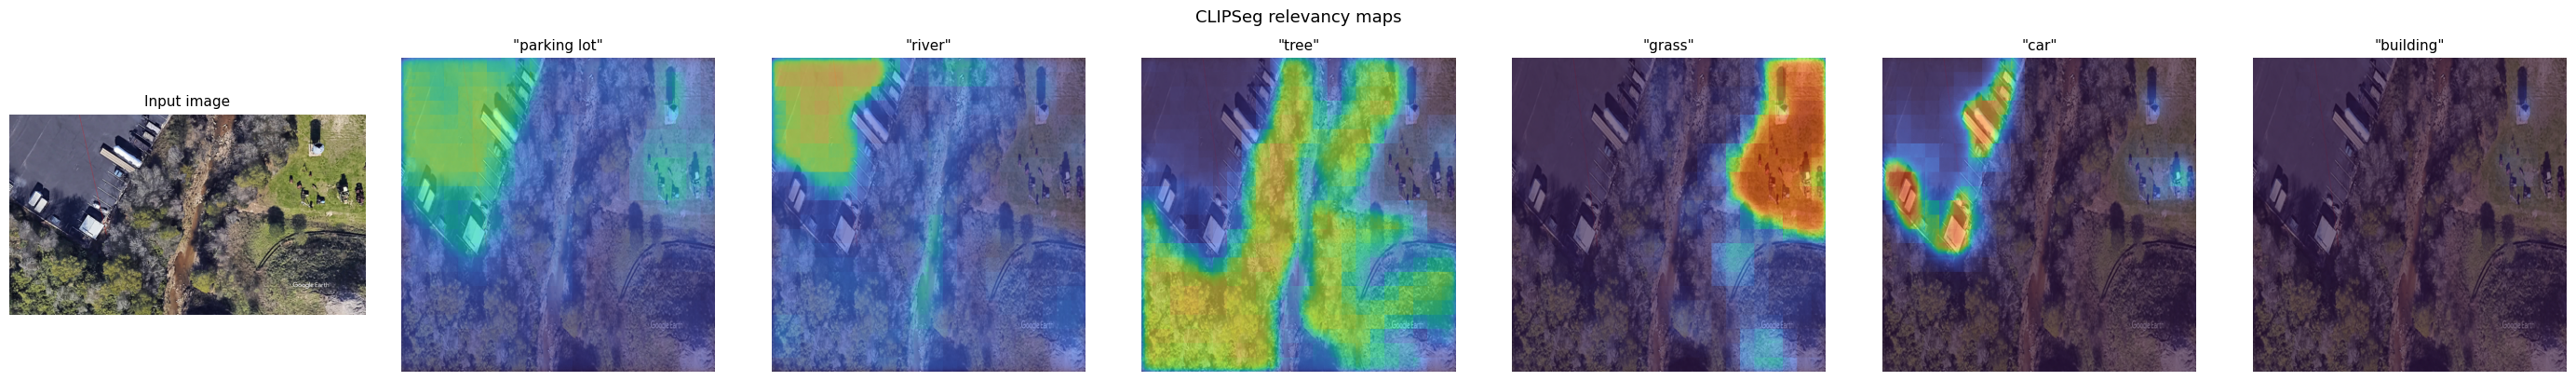

In [27]:
fig, axes = plt.subplots(1, len(queries) + 1, figsize=(4 * (len(queries) + 1), 4))

axes[0].imshow(image)
axes[0].set_title("Input image", fontsize=11)
axes[0].axis("off")

for i, query in enumerate(queries):
    ax  = axes[i + 1]
    rel = relevancy[i]                          # (352, 352)
    ax.imshow(image.resize((352, 352)))         # faint background
    ax.imshow(rel, alpha=0.6, cmap="turbo",
              vmin=0, vmax=1)
    ax.set_title(f'"{query}"', fontsize=11)
    ax.axis("off")

plt.suptitle("CLIPSeg relevancy maps", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1672855/2054520713.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(queries))


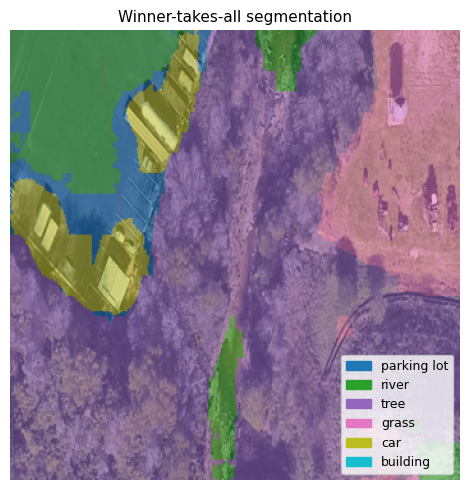

In [28]:
winner = np.argmax(relevancy, axis=0)          # (352, 352)  int index

cmap   = plt.cm.get_cmap("tab10", len(queries))
colors = [cmap(i) for i in range(len(queries))]
legend_patches = [
    plt.matplotlib.patches.Patch(color=colors[i], label=queries[i])
    for i in range(len(queries))
]

fig2, ax2 = plt.subplots(1, 1, figsize=(6, 5))
ax2.imshow(image.resize((352, 352)))
seg_rgba = np.zeros((352, 352, 4))
for i in range(len(queries)):
    mask = winner == i
    seg_rgba[mask] = (*colors[i][:3], 0.55)    # colour + alpha

ax2.imshow(seg_rgba)
ax2.legend(handles=legend_patches, loc="lower right", fontsize=9)
ax2.set_title("Winner-takes-all segmentation", fontsize=11)
ax2.axis("off")
plt.tight_layout()
plt.show()